In [4]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Analyze Results

In [5]:
path_to_summary = Path(os.getcwd()).parent / "runs" / "STL10" / "summary" / "summary.csv"
df = pd.read_csv(path_to_summary)
df.head()

,bottleneck,load_best,freeze_features,lr,weight_decay,epochs,tag,final_train_loss,final_train_acc,final_test_acc
0,avg_8x8,True,False,0.10,0.0005,20,lr_tuning,0.631282,73.32,67.200
1,avg_8x8,True,True,0.10,0.0005,20,lr_tuning,0.504944,79.12,71.600
2,avg_8x8,False,False,0.10,0.0005,20,lr_tuning,0.493322,81.08,65.675
3,avg_8x8,True,False,0.01,0.0005,20,lr_tuning,0.538481,78.28,73.150
4,avg_8x8,True,True,0.01,0.0005,20,lr_tuning,0.617389,74.44,70.900


In [6]:
def apply_label(row: pd.Series) -> str:
    freeze_features = row["freeze_features"]
    load_best = row["load_best"]
    return f"ff_{freeze_features}_lb_{load_best}"

df["label"] = df.apply(apply_label, axis=1)
df.head()

,bottleneck,load_best,freeze_features,lr,weight_decay,epochs,tag,final_train_loss,final_train_acc,final_test_acc,label
0,avg_8x8,True,False,0.10,0.0005,20,lr_tuning,0.631282,73.32,67.200,ff_False_lb_True
1,avg_8x8,True,True,0.10,0.0005,20,lr_tuning,0.504944,79.12,71.600,ff_True_lb_True
2,avg_8x8,False,False,0.10,0.0005,20,lr_tuning,0.493322,81.08,65.675,ff_False_lb_False
3,avg_8x8,True,False,0.01,0.0005,20,lr_tuning,0.538481,78.28,73.150,ff_False_lb_True
4,avg_8x8,True,True,0.01,0.0005,20,lr_tuning,0.617389,74.44,70.900,ff_True_lb_True


In [7]:
df[df.bottleneck == "avg_8x8"].sort_values(by="final_test_acc", ascending=False)

,bottleneck,load_best,freeze_features,lr,weight_decay,epochs,tag,final_train_loss,final_train_acc,final_test_acc,label
3,avg_8x8,True,False,0.0100,0.0005,20,lr_tuning,0.538481,78.28,73.150,ff_False_lb_True
1,avg_8x8,True,True,0.1000,0.0005,20,lr_tuning,0.504944,79.12,71.600,ff_True_lb_True
4,avg_8x8,True,True,0.0100,0.0005,20,lr_tuning,0.617389,74.44,70.900,ff_True_lb_True
0,avg_8x8,True,False,0.1000,0.0005,20,lr_tuning,0.631282,73.32,67.200,ff_False_lb_True
2,avg_8x8,False,False,0.1000,0.0005,20,lr_tuning,0.493322,81.08,65.675,ff_False_lb_False
6,avg_8x8,True,False,0.0010,0.0005,20,lr_tuning,0.904415,64.16,64.350,ff_False_lb_True
7,avg_8x8,True,True,0.0010,0.0005,20,lr_tuning,0.908253,63.04,63.050,ff_True_lb_True
5,avg_8x8,False,False,0.0100,0.0005,20,lr_tuning,1.016032,58.76,55.200,ff_False_lb_False
10,avg_8x8,True,True,0.0001,0.0005,20,lr_tuning,1.449195,51.64,51.000,ff_True_lb_True
9,avg_8x8,True,False,0.0001,0.0005,20,lr_tuning,1.476962,47.04,47.925,ff_False_lb_True


In [8]:
best_performance = df.groupby(
    ["bottleneck", "freeze_features", "load_best"]
)["final_test_acc"].max().reset_index()
best_performance_with_lr = best_performance.merge(
    df,
    on=["bottleneck", "freeze_features", "load_best", "final_test_acc"],
    how="left"
)

In [9]:
best_performance_with_lr[["bottleneck", "load_best", "freeze_features", "lr", "final_test_acc"]][best_performance_with_lr.load_best == False].sort_values(by=["final_test_acc"], ascending=False)

,bottleneck,load_best,freeze_features,lr,final_test_acc
21,max_8x8,False,False,0.010,66.725
9,avg_8x8,False,False,0.100,65.675
6,5x5_conv,False,False,0.010,61.775
12,global_avg,False,False,0.100,61.175
15,global_max,False,False,0.010,58.950
0,2x2_conv,False,False,0.010,57.750
18,linear,False,False,0.001,57.300
3,3x3_conv,False,False,0.010,56.800


In [10]:
best_best_performance = best_performance_with_lr.groupby(
    ["bottleneck"]
)["final_test_acc"].min().reset_index()
best_best_performance_with_lr = best_best_performance.merge(
    df,
    on=["bottleneck", "final_test_acc"],
    how="left"
)
best_best_performance_with_lr[["bottleneck", "freeze_features", "load_best", "lr", "final_test_acc"]].sort_values(by="final_test_acc", ascending=False)

,bottleneck,freeze_features,load_best,lr,final_test_acc
7,max_8x8,True,True,0.010,65.925
3,avg_8x8,False,False,0.100,65.675
2,5x5_conv,False,False,0.010,61.775
4,global_avg,False,False,0.100,61.175
0,2x2_conv,False,False,0.010,57.750
6,linear,False,False,0.001,57.300
1,3x3_conv,False,False,0.010,56.800
5,global_max,True,True,0.010,51.075


## Plot embeddings

In [15]:

from utils import load_embeddings

def get_hyperparam_conf(row: pd.Series):
    return f"load_best={row.load_best}_bottleneck={row.bottleneck}_freeze_fts={row.freeze_features}_lr={row.lr}_epochs={row.epochs}_wd={row.weight_decay}"

path_to_experiment = Path(os.getcwd()).parent / "runs" / "STL10"

best_performances = best_best_performance_with_lr[best_best_performance_with_lr.bottleneck.isin(["max_8x8", "linear", "5x5_conv", "global_avg"])]

embeddings = {}

for _, row in best_performances.iterrows():
    hyperparam_conf = get_hyperparam_conf(row)
    path_to_embeddings = path_to_experiment / hyperparam_conf / "artifacts" / "embeddings" / "embeddings.npz"
    train_embeddings, test_embeddings, y_train, y_test = load_embeddings(path_to_embeddings)

    # Flatten embeddings
    train_embeddings = train_embeddings.reshape(train_embeddings.shape[0], -1)
    test_embeddings = test_embeddings.reshape(test_embeddings.shape[0], -1)

    print(f"Loaded embeddings from: {row.bottleneck} with shape: {train_embeddings.shape}")
    embeddings[row.bottleneck] = (train_embeddings, test_embeddings)

Loaded embeddings from: 5x5_conv with shape: (2500, 108)
Loaded embeddings from: global_avg with shape: (2500, 120)
Loaded embeddings from: linear with shape: (2500, 34680)
Loaded embeddings from: max_8x8 with shape: (2500, 480)


In [19]:
embeddings.keys()

dict_keys(['5x5_conv', 'global_avg', 'linear', 'max_8x8'])

Plotted t-SNE for 5x5_conv
Plotted t-SNE for global_avg
Plotted t-SNE for linear
Plotted t-SNE for max_8x8


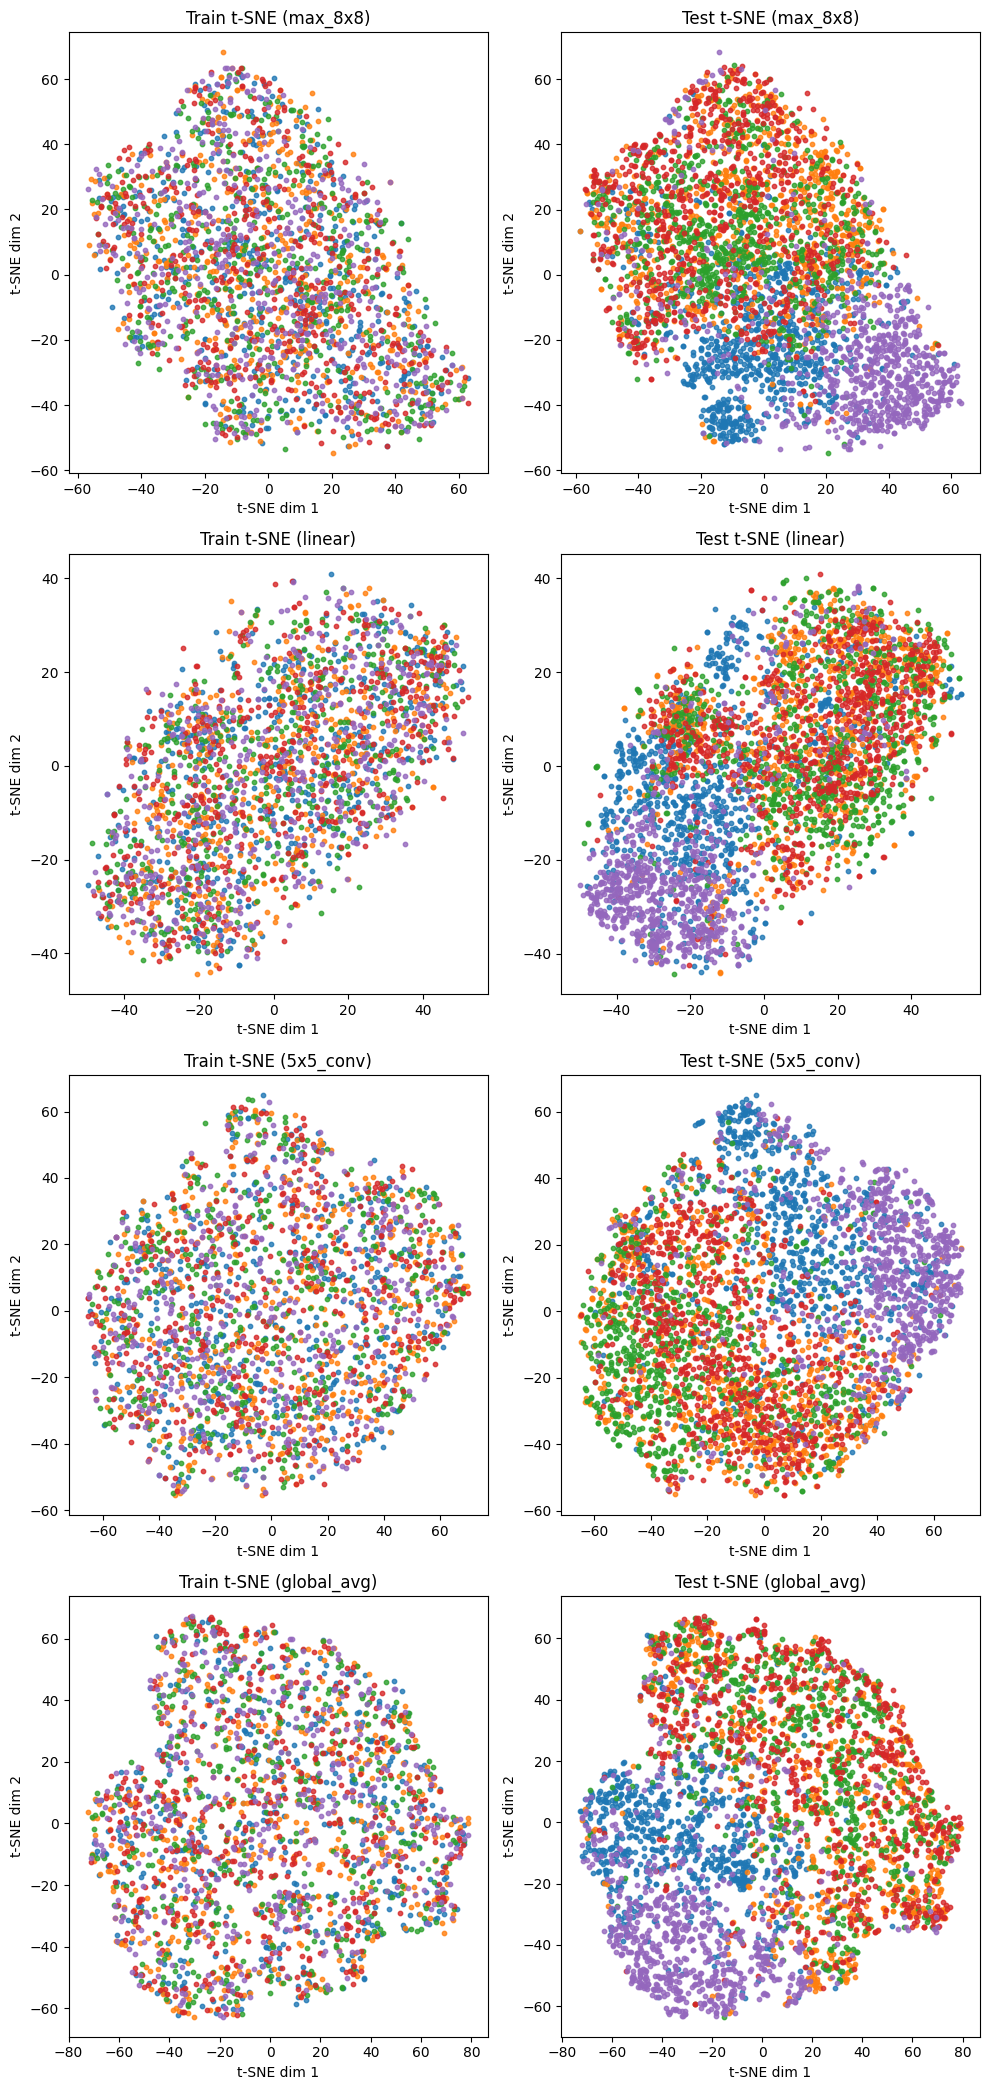

In [28]:
from plot import plot_tsne
import matplotlib.pyplot as plt

fig, ([ax_max_train, ax_max_test], [ax_lin_train, ax_lin_test], [ax_5x5_train, ax_5x5_test], [ax_glob_train, ax_glob_test]) = \
    plt.subplots(4, 2, figsize=(10, 21))

embeddings_axs = {
    "5x5_conv": (ax_5x5_train, ax_5x5_test),
    "global_avg": (ax_glob_train, ax_glob_test),
    "linear": (ax_lin_train, ax_lin_test),
    "max_8x8": (ax_max_train, ax_max_test)
}

for bottleneck, (train_ax, test_ax) in embeddings_axs.items():
    plot_tsne(
        embeddings[bottleneck][0],
        y_train,
        embeddings[bottleneck][1],
        y_test,
        ax_train=train_ax,
        ax_test=test_ax,
        train_title=f"Train t-SNE ({bottleneck})",
        test_title=f"Test t-SNE ({bottleneck})",
        # fig_path=Path("tsne_best_embeddings") / f"tsne_{bottleneck}"
    )
    print(f"Plotted t-SNE for {bottleneck}")

# plt.suptitle("t-SNE Visualization of Best Embeddings per Bottleneck Type", fontsize=16)

plt.tight_layout()
plt.savefig("tsne_best_embeddings.png", dpi=100)
plt.show()

In [29]:
worst_best_performance = best_performance_with_lr.groupby(
    ["bottleneck"]
)["final_test_acc"].min().reset_index()
worst_best_performance_with_lr = worst_best_performance.merge(
    df,
    on=["bottleneck", "final_test_acc"],
    how="left"
)
worst_best_performance_with_lr[["bottleneck", "freeze_features", "load_best", "lr", "final_test_acc"]].sort_values(by="final_test_acc", ascending=False)

,bottleneck,freeze_features,load_best,lr,final_test_acc
7,max_8x8,True,True,0.010,65.925
3,avg_8x8,False,False,0.100,65.675
2,5x5_conv,False,False,0.010,61.775
4,global_avg,False,False,0.100,61.175
0,2x2_conv,False,False,0.010,57.750
6,linear,False,False,0.001,57.300
1,3x3_conv,False,False,0.010,56.800
5,global_max,True,True,0.010,51.075


In [30]:

from utils import load_embeddings

def get_hyperparam_conf(row: pd.Series):
    return f"load_best={row.load_best}_bottleneck={row.bottleneck}_freeze_fts={row.freeze_features}_lr={row.lr}_epochs={row.epochs}_wd={row.weight_decay}"

path_to_experiment = Path(os.getcwd()).parent / "runs" / "STL10"

best_performances = worst_best_performance_with_lr[worst_best_performance_with_lr.bottleneck.isin(["avg_8x8", "linear", "2x2_conv", "global_max"])]

embeddings = {}

for _, row in best_performances.iterrows():
    hyperparam_conf = get_hyperparam_conf(row)
    path_to_embeddings = path_to_experiment / hyperparam_conf / "artifacts" / "embeddings" / "embeddings.npz"
    train_embeddings, test_embeddings, y_train, y_test = load_embeddings(path_to_embeddings)

    # Flatten embeddings
    train_embeddings = train_embeddings.reshape(train_embeddings.shape[0], -1)
    test_embeddings = test_embeddings.reshape(test_embeddings.shape[0], -1)

    print(f"Loaded embeddings from: {row.bottleneck} with shape: {train_embeddings.shape}")
    embeddings[row.bottleneck] = (train_embeddings, test_embeddings)

Loaded embeddings from: 2x2_conv with shape: (2500, 256)
Loaded embeddings from: avg_8x8 with shape: (2500, 480)
Loaded embeddings from: global_max with shape: (2500, 120)
Loaded embeddings from: linear with shape: (2500, 34680)


Plotted t-SNE for avg_8x8
Plotted t-SNE for linear
Plotted t-SNE for 2x2_conv
Plotted t-SNE for global_max


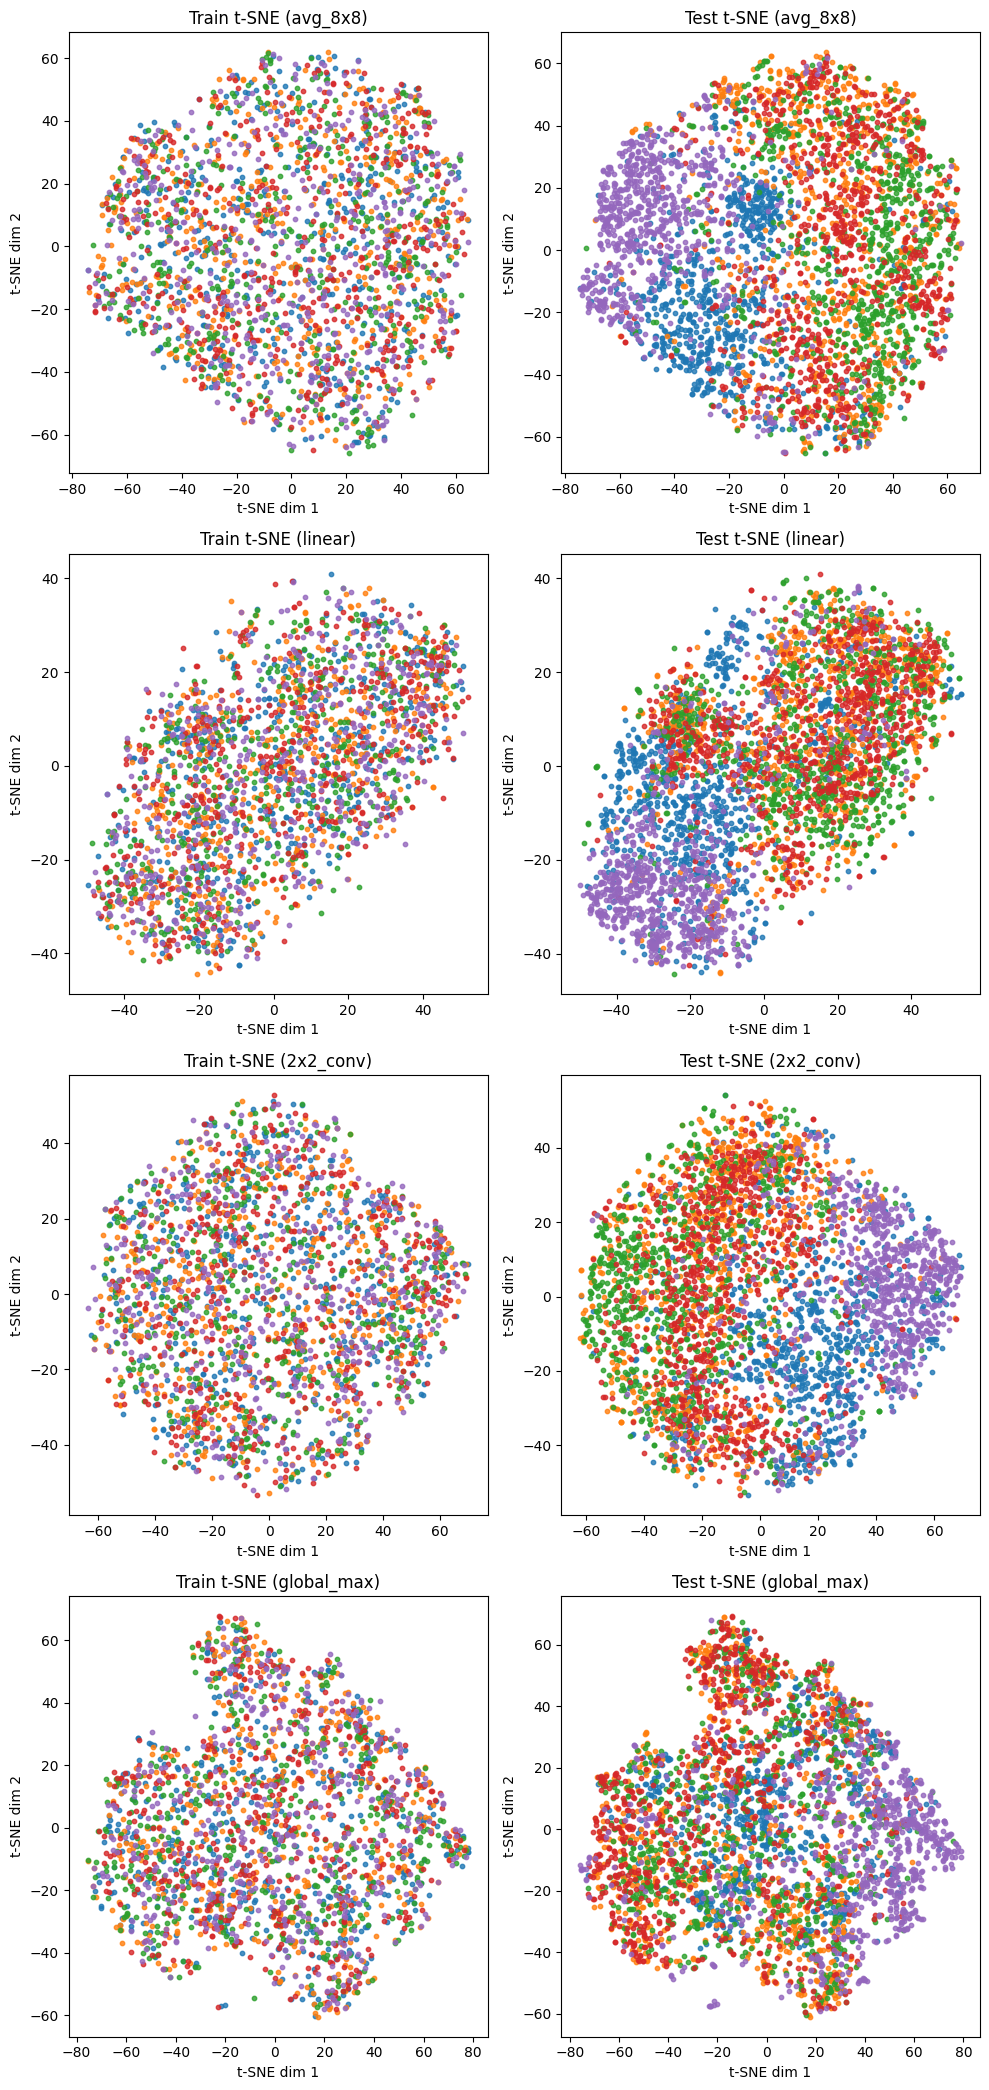

In [31]:
from plot import plot_tsne
import matplotlib.pyplot as plt

fig, ([avg_8x8_train, avg_8x8_test], [ax_lin_train, ax_lin_test], [ax_2x2_train, ax_2x2_test], [ax_glob_train, ax_glob_test]) = \
    plt.subplots(4, 2, figsize=(10, 21))

embeddings_axs = {
    "avg_8x8": (avg_8x8_train, avg_8x8_test),
    "linear": (ax_lin_train, ax_lin_test),
    "2x2_conv": (ax_2x2_train, ax_2x2_test),
    "global_max": (ax_glob_train, ax_glob_test),
}

for bottleneck, (train_ax, test_ax) in embeddings_axs.items():
    plot_tsne(
        embeddings[bottleneck][0],
        y_train,
        embeddings[bottleneck][1],
        y_test,
        ax_train=train_ax,
        ax_test=test_ax,
        train_title=f"Train t-SNE ({bottleneck})",
        test_title=f"Test t-SNE ({bottleneck})",
        # fig_path=Path("tsne_best_embeddings") / f"tsne_{bottleneck}"
    )
    print(f"Plotted t-SNE for {bottleneck}")

# plt.suptitle("t-SNE Visualization of Best Embeddings per Bottleneck Type", fontsize=16)

plt.tight_layout()
plt.savefig("tsne_worst_embeddings.png", dpi=100)
plt.show()

In [34]:
second_best_performance = best_performance_with_lr.groupby(
    ["bottleneck", "freeze_features", "load_best"]
)["final_test_acc"].nth(2).reset_index()
second_best_performance
# second_best_performance_with_lr = second_best_performance.merge(
#     df,
#     on=["bottleneck", "freeze_features", "load_best", "final_test_acc"],
#     how="left"
# )
# second_best_performance_with_lr[["bottleneck", "freeze_features", "load_best", "lr", "final_test_acc"]].sort_values(by="final_test_acc", ascending=False)

,index,final_test_acc
